# LMS-Based Schizophrenia Classification on Dataset 1 using Statistical and Entropy Features

This notebook implements an EEG schizophrenia classification pipeline on Dataset 1 using LMS-based adaptive filtering.

The EEG recordings are segmented into 5-second windows, filtered using an LMS procedure with the Fp1 channel as reference, and transformed into feature vectors based on statistical and entropy-related descriptors.

The Fp1 channel is used as the reference signal in the LMS adaptive filtering stage.
This choice is motivated by its frontal location and its potential sensitivity to artifacts and correlated activity.

The resulting features are then used to train and evaluate machine learning classifiers.

In [2]:
import mne
from glob import glob
import numpy as np
from PyEMD import EMD
from scipy.signal import hilbert, lfilter, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed
from sklearn.svm import SVC
from sklearn.model_selection import KFold, cross_val_score

In [3]:
def load_eeg(file_path):
    raw = mne.io.read_raw_edf(file_path, preload=True)
    return raw.get_data()

def segment_signal(signal, segment_duration, fs):

    segment_length = int(segment_duration * fs)
    return [signal[:, i:i+segment_length]
            for i in range(0, signal.shape[1], segment_length)]

In [4]:
healthy_file_paths = sorted(glob("dataverse_files/h*.edf"))
schizo_file_paths  = sorted(glob("dataverse_files/s*.edf"))

healthy_signals = [load_eeg(file) for file in healthy_file_paths]
schizo_signals  = [load_eeg(file) for file in schizo_file_paths]

fs = 250
segment_duration = 5

healthy_segments = [segment_signal(sig, segment_duration, fs) for sig in healthy_signals]
schizo_segments  = [segment_signal(sig, segment_duration, fs) for sig in schizo_signals]

Extracting EDF parameters from /content/dataverse_files/h01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 227499  =      0.000 ...   909.996 secs...
Extracting EDF parameters from /content/dataverse_files/h04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 231249  =      0.000 ...   924.996 secs...
Extracting EDF parameters from /content/dataverse_files/h05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 236249  

In [5]:
healthy_segments = [seg for subj in healthy_segments for seg in subj if seg.shape[1] > 0]
schizo_segments  = [seg for subj in schizo_segments for seg in subj if seg.shape[1] > 0]

## LMS Adaptive Filtering

Least Mean Squares (LMS) adaptive filtering is applied to each EEG segment.

In this implementation, the Fp1 channel is used as the reference channel.  
For each of the other channels, the LMS filter adaptively estimates and removes components correlated with the reference signal.

In [ ]:
def lms_filter_1coeff(imf, ref, mu=0.005):

    n_times = len(imf)
    output = np.zeros(n_times)
    w = 0.0
    for i in range(n_times):
        e = imf[i] - w * ref[i]
        w = w + 2 * mu * e * ref[i]
        output[i] = imf[i] - e
    return output


In [ ]:
def lms_filter_fp1_allch(signal, fp1_index=0, mu=0.005):
    signal = np.asarray(signal)
    n_channels, n_times = signal.shape

    filtered = np.zeros_like(signal)

    filtered[fp1_index, :] = signal[fp1_index, :]

    for ch in range(n_channels):
        if ch == fp1_index:
            continue
        filtered[ch, :] = lms_filter_1coeff(
            imf=signal[ch, :],
            ref=signal[fp1_index, :],
            mu=mu
        )
    return filtered

In [ ]:
healthy_segments_filtered = Parallel(n_jobs=-1)(
    delayed(lms_filter_fp1_allch)(seg, fp1_index=0, mu=0.005)
    for seg in healthy_segments
)
schizo_segments_filtered = Parallel(n_jobs=-1)(
    delayed(lms_filter_fp1_allch)(seg, fp1_index=0, mu=0.005)
    for seg in schizo_segments
)

In [8]:
def compute_energy_1d(signal_1d):
    return np.sum(signal_1d**2)

def compute_std_1d(signal_1d):
    return np.std(signal_1d)

def compute_shannon_entropy_1d(signal_1d, eps=1e-10):
    abs_sig = np.abs(signal_1d)
    sum_sig = np.sum(abs_sig) + eps
    probs = abs_sig / sum_sig
    return -np.sum(probs * np.log(probs + eps))

def extract_features_per_segment(signal_2d):

    n_channels, n_times = signal_2d.shape
    feats = []
    for ch in range(n_channels):
        x = signal_2d[ch, :]
        en = compute_energy_1d(x)
        sd = compute_std_1d(x)
        ent = compute_shannon_entropy_1d(x)
        feats.extend([en, sd, ent])
    return np.array(feats)

In [ ]:
healthy_features = [extract_features_per_segment(seg) for seg in healthy_segments_filtered]
schizo_features  = [extract_features_per_segment(seg) for seg in schizo_segments_filtered]

X = np.vstack([healthy_features, schizo_features])
y = np.array([0]*len(healthy_features) + [1]*len(schizo_features))  # 0 = healthy, 1 = schizo

In [ ]:
# KFold Cross Validation Random Forest

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=kf, scoring='accuracy')
print(f"Random Forest - KFold CV scores: {rf_scores}")
print(f"Random Forest - Mean CV accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

Random Forest - KFold CV scores: [0.88917749 0.88398268 0.9012987  0.89350649 0.8961039 ]
Random Forest - Mean CV accuracy: 0.893 ± 0.006


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rf.fit(X_train, y_train)

y_pred_rf = clf_rf.predict(X_test)
print("Random Forest :")
print(classification_report(y_test, y_pred_rf))
print("Accuracy =", accuracy_score(y_test, y_pred_rf))

Random Forest :
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       521
           1       0.91      0.90      0.90       634

    accuracy                           0.90      1155
   macro avg       0.89      0.89      0.89      1155
weighted avg       0.90      0.90      0.90      1155

Accuracy = 0.8952380952380953


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.89      0.88       521
           1       0.91      0.90      0.90       634

    accuracy                           0.90      1155
   macro avg       0.89      0.89      0.89      1155
weighted avg       0.90      0.90      0.90      1155



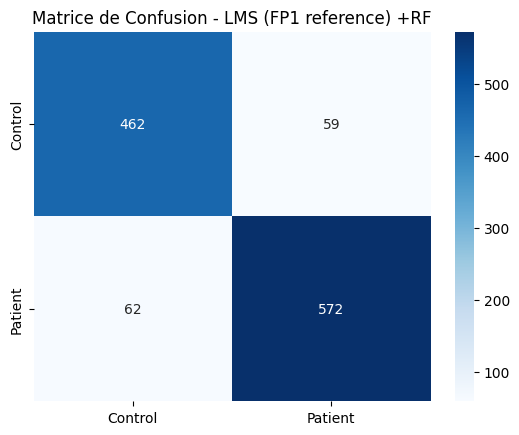

In [ ]:
y_pred = clf_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control","Patient"], yticklabels=["Control","Patient"])
plt.title("Matrice de Confusion - LMS (FP1 reference) +RF")
plt.show()

**SVM**

In [ ]:
# KFold Cross Validation SVM

kf = KFold(n_splits=5, shuffle=True, random_state=42)

clf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rf_scores = cross_val_score(clf_svm, X, y, cv=kf, scoring='accuracy')
print(f"SVM - KFold CV scores: {rf_scores}")
print(f"SVM - Mean CV accuracy: {rf_scores.mean():.3f} ± {rf_scores.std():.3f}")

SVM - KFold CV scores: [0.68398268 0.66493506 0.7012987  0.68051948 0.68225108]
SVM - Mean CV accuracy: 0.683 ± 0.012


In [ ]:
clf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
clf_svm.fit(X_train, y_train)

y_pred_svm = clf_svm.predict(X_test)
print("SVM :")
print(classification_report(y_test, y_pred_svm))
print("Accuracy =", accuracy_score(y_test, y_pred_svm))

SVM :
              precision    recall  f1-score   support

           0       0.60      0.81      0.69       521
           1       0.78      0.56      0.65       634

    accuracy                           0.67      1155
   macro avg       0.69      0.68      0.67      1155
weighted avg       0.70      0.67      0.67      1155

Accuracy = 0.670995670995671


=== SVM ===
              precision    recall  f1-score   support

           0       0.60      0.81      0.69       521
           1       0.78      0.56      0.65       634

    accuracy                           0.67      1155
   macro avg       0.69      0.68      0.67      1155
weighted avg       0.70      0.67      0.67      1155



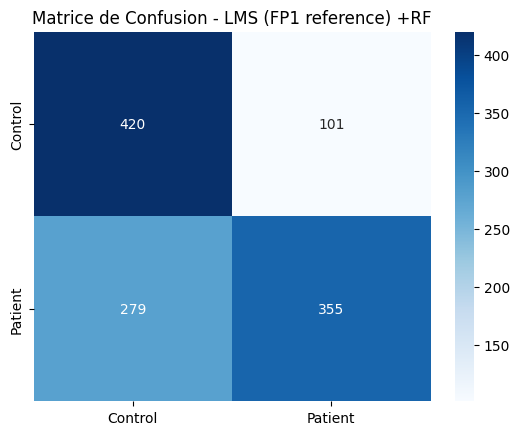

In [ ]:
y_pred = clf_svm.predict(X_test)

print("=== SVM ===")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Control","Patient"], yticklabels=["Control","Patient"])
plt.title("Matrice de Confusion - LMS (FP1 reference) +SVM")
plt.show()